In [10]:
# MVP Hello World: Coleta simples e modelo mínimo
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt

In [11]:
symbol = 'AAPL'  # Ou 'PETR4.SA' para Petrobras
df = yf.download(symbol, start='2018-01-01', end='2024-12-31')
data = df[['Close']].values

/tmp/ipykernel_126629/2247560179.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start='2018-01-01', end='2024-12-31')
[*********************100%***********************]  1 of 1 completed


In [12]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [13]:
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

seq_length = 60
X, y = create_sequences(data_scaled, seq_length)
X = X.reshape((X.shape[0], X.shape[1], 1))

In [14]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [15]:
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(seq_length, 1)),
    LSTM(50),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.summary()

/home/isapt/docs/lstm-predict/.venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - loss: 0.0237 - val_loss: 0.0027
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 5.8632e-04 - val_loss: 0.0012
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 5.0642e-04 - val_loss: 0.0018
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 4.8997e-04 - val_loss: 0.0014
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 4.8582e-04 - val_loss: 0.0013
Epoch 6/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 4.7339e-04 - val_loss: 9.8385e-04
Epoch 7/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 4.4290e-04 - val_loss: 0.0011
Epoch 8/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 4.6413e-04 - val_loss: 0.0013
Epoch 9/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 4.3314e-04 - val_loss: 9.2479e-04
Epoch 10/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 4.0624e-04 - val_loss: 0.0011
Epoch 11/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 4.0661e-04 - val_loss: 0.0012
Epoch 12/20
43/

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
MAE: 9.00, RMSE: 10.54, MAPE: 4.38%


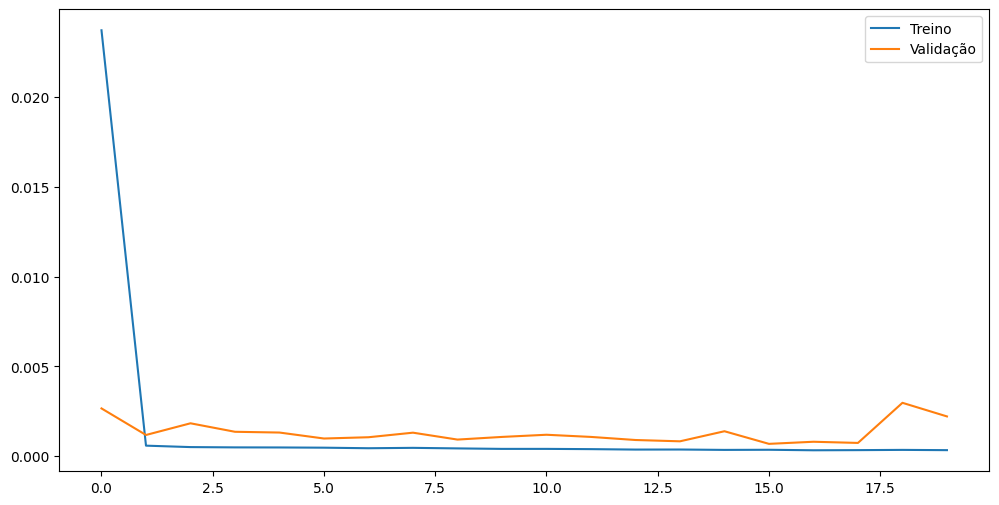

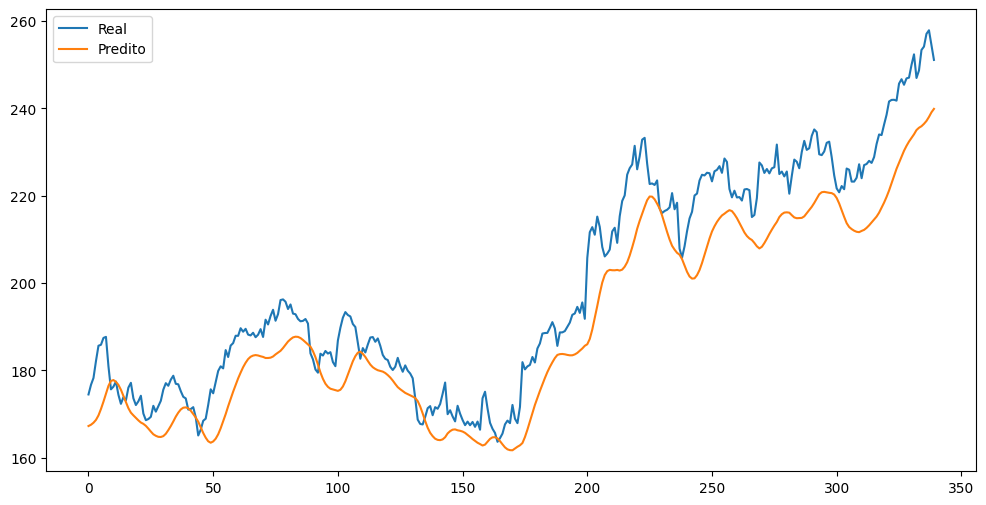

Modelo treinado e salvo!


In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import joblib

preds = model.predict(X_test)
preds = scaler.inverse_transform(preds)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

mae = mean_absolute_error(y_test_inv, preds)
rmse = np.sqrt(mean_squared_error(y_test_inv, preds))
mape = np.mean(np.abs((y_test_inv - preds) / y_test_inv)) * 100

print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%")

# Plots
plt.figure(figsize=(12,6))
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.legend()
plt.show()

plt.figure(figsize=(12,6))
plt.plot(y_test_inv, label='Real')
plt.plot(preds, label='Predito')
plt.legend()
plt.show()

# Salvar
model.save('../models/lstm_mvp.keras')
joblib.dump(scaler, '../models/scaler.pkl')
print("Modelo treinado e salvo!")